Dataset Extracted Successfully
Dataset Path: ./extracted_dataset/Covid19-dataset
Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.

Classes:
{'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Training: CNN
Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.3825 - loss: 2.1699 - val_accuracy: 0.4697 - val_loss: 1.0111
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 704ms/step - accuracy: 0.7371 - loss: 0.6665 - val_accuracy: 0.7879 - val_loss: 0.4545
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 825ms/step - accuracy: 0.8725 - loss: 0.3199 - val_accuracy: 0.8030 - val_loss: 0.4238
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 734ms/step - accuracy: 0.9044 - loss: 0.2431 - val_accuracy: 0.8485 - val_loss: 0.3603
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 840ms/step - accuracy: 0.9363 - loss: 0.1862 - val_accuracy: 0.8030 - val_l

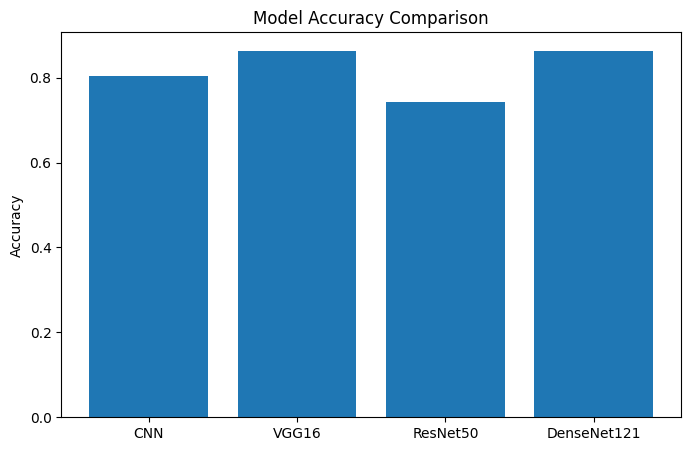

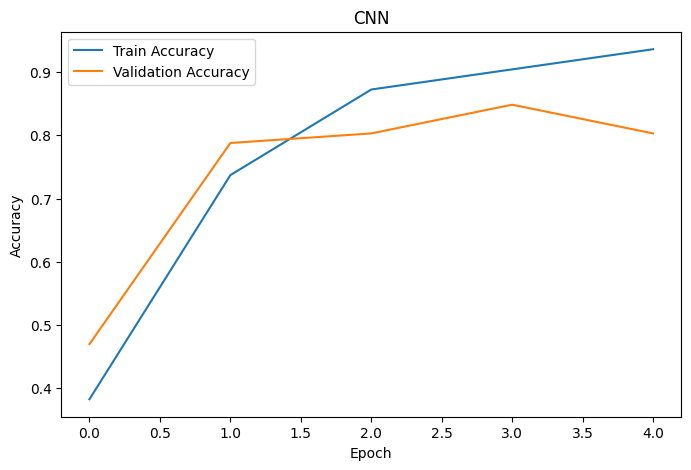

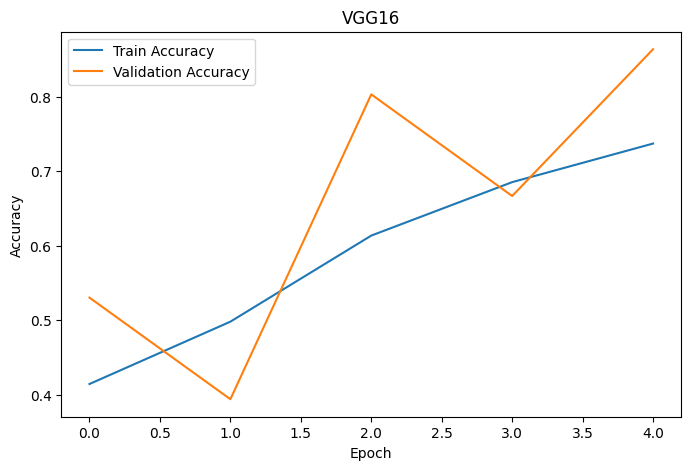

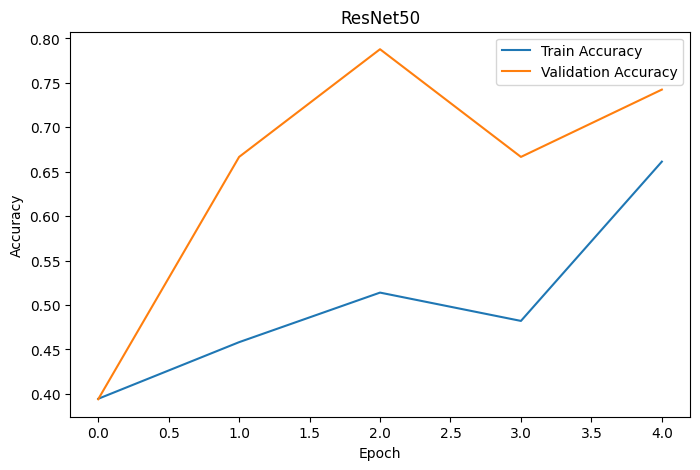

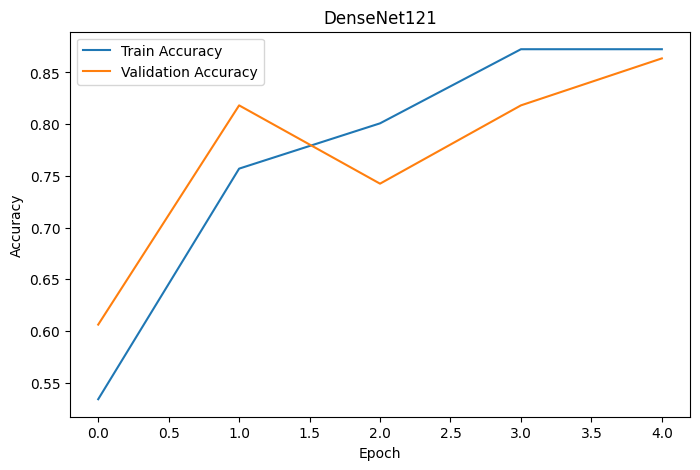


Best Model: VGG16
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 374ms/step


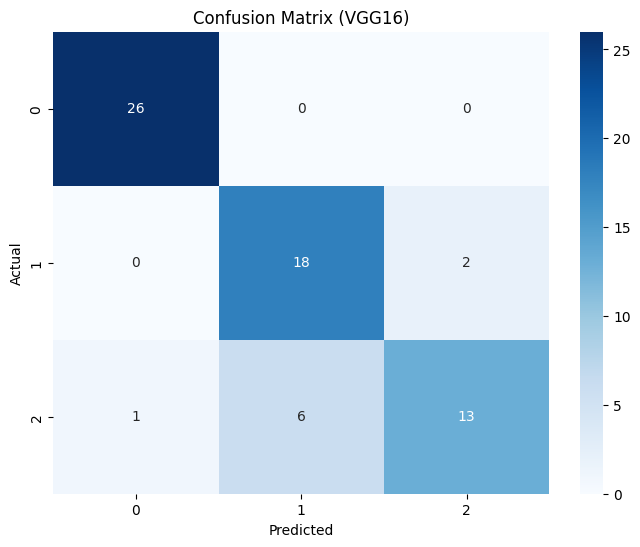

                 precision    recall  f1-score   support

          Covid       0.96      1.00      0.98        26
         Normal       0.75      0.90      0.82        20
Viral Pneumonia       0.87      0.65      0.74        20

       accuracy                           0.86        66
      macro avg       0.86      0.85      0.85        66
   weighted avg       0.87      0.86      0.86        66



In [2]:
# ==============================
# COMPLETE SINGLE-CELL PROJECT
# ==============================

import os
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import tensorflow as tf

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

from tensorflow.keras.models import Model, Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import (
    VGG16,
    ResNet50,
    DenseNet121
)

# ==========================================
# STEP 1 : EXTRACT ZIP FILE
# ==========================================

ZIP_FILE = "archive (3).zip"

EXTRACT_PATH = "./extracted_dataset/"

with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset Extracted Successfully")

# ==========================================
# STEP 2 : FIND DATASET FOLDER
# ==========================================

dataset_path = None

for root, dirs, files in os.walk(EXTRACT_PATH):
    if len(dirs) >= 2:
        dataset_path = root
        break

print("Dataset Path:", dataset_path)

# ==========================================d
# STEP 3 : IMAGE GENERATOR
# ==========================================

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5

# Create separate data generators for training and testing
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

# Check if the directories exist (optional, but good for debugging)
if not os.path.exists(train_dir):
    print(f"Error: Training directory not found at {train_dir}")
if not os.path.exists(test_dir):
    print(f"Error: Testing directory not found at {test_dir}")

train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)

print("\nClasses:")
print(train_generator.class_indices)

# ==========================================
# STEP 4 : CNN MODEL
# ==========================================

def CNN_Model():

    model = Sequential([

        Conv2D(
            32,
            (3,3),
            activation='relu',
            input_shape=(224,224,3)
        ),

        MaxPooling2D(),

        Conv2D(
            64,
            (3,3),
            activation='relu'
        ),

        MaxPooling2D(),

        Conv2D(
            128,
            (3,3),
            activation='relu'
        ),

        MaxPooling2D(),

        Flatten(),

        Dense(
            256,
            activation='relu'
        ),

        Dropout(0.5),

        Dense(
            NUM_CLASSES,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================
# STEP 5 : VGG16
# ==========================================

def VGG16_Model():

    base = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)

    x = Dense(
        256,
        activation='relu'
    )(x)

    x = Dropout(0.5)(x)

    output = Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    model = Model(
        base.input,
        output
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================
# STEP 6 : RESNET50
# ==========================================

def ResNet_Model():

    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)

    x = Dense(
        256,
        activation='relu'
    )(x)

    x = Dropout(0.5)(x)

    output = Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    model = Model(
        base.input,
        output
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================
# STEP 7 : DENSENET121
# ==========================================

def DenseNet_Model():

    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)

    x = Dense(
        256,
        activation='relu'
    )(x)

    x = Dropout(0.5)(x)

    output = Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    model = Model(
        base.input,
        output
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================
# STEP 8 : TRAIN ALL MODELS
# ==========================================

models = {
    "CNN": CNN_Model(),
    "VGG16": VGG16_Model(),
    "ResNet50": ResNet_Model(),
    "DenseNet121": DenseNet_Model()
}

histories = {}
accuracies = {}

for name, model in models.items():

    print("\n")
    print("="*50)
    print("Training:", name)
    print("="*50)

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        verbose=1
    )

    loss, acc = model.evaluate(
        val_generator,
        verbose=0
    )

    histories[name] = history
    accuracies[name] = acc

    print(name, "Accuracy:", round(acc*100,2), "%")

# ==========================================
# STEP 9 : ACCURACY COMPARISON
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    accuracies.keys(),
    accuracies.values()
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

# ==========================================
# STEP 10 : TRAINING CURVES
# ==========================================

for name, history in histories.items():

    plt.figure(figsize=(8,5))

    plt.plot(
        history.history['accuracy'],
        label='Train Accuracy'
    )

    plt.plot(
        history.history['val_accuracy'],
        label='Validation Accuracy'
    )

    plt.title(name)

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.legend()

    plt.show()

# ==========================================
# STEP 11 : BEST MODEL
# ==========================================

best_model_name = max(
    accuracies,
    key=accuracies.get
)

best_model = models[
    best_model_name
]

print("\nBest Model:", best_model_name)

# ==========================================
# STEP 12 : CONFUSION MATRIX
# ==========================================

predictions = best_model.predict(
    val_generator
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = val_generator.classes

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f'Confusion Matrix ({best_model_name})'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# ==========================================
# STEP 13 : CLASSIFICATION REPORT
# ==========================================

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(
            train_generator.class_indices.keys()
        )
    )
)

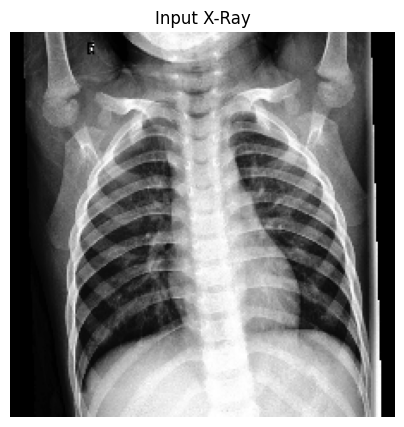


Prediction Probabilities:
----------------------------------------
Covid               : 7.36%
Normal              : 52.87%
Viral Pneumonia     : 39.78%

FINAL PREDICTION
Predicted Disease : Normal
Confidence Score  : 52.87%


In [12]:
# ==========================================
# STEP 14 : PREDICT NEW IMAGE (SEPARATE CELL)
# ==========================================

import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array
)

# Enter test image path
IMAGE_PATH = "TENORM2.jpeg"   # Change image name if needed

if not os.path.exists(IMAGE_PATH):
    print(f"Error: Image not found -> {IMAGE_PATH}")

else:

    # Load image
    img = load_img(
        IMAGE_PATH,
        target_size=(224, 224)
    )

    # Display image
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input X-Ray")
    plt.show()

    # Preprocess image
    img_array = img_to_array(img)

    img_array = img_array.astype("float32") / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Prediction
    pred = best_model.predict(
        img_array,
        verbose=0
    )

    # Class names
    classes = list(
        train_generator.class_indices.keys()
    )

    # Probabilities
    print("\nPrediction Probabilities:")
    print("-"*40)

    for i, cls in enumerate(classes):
        print(
            f"{cls:<20}: {pred[0][i]*100:.2f}%"
        )

    # Best prediction
    max_prob = np.max(pred)

    predicted_index = np.argmax(pred)

    disease = classes[predicted_index]

    confidence = max_prob * 100

    # Confidence threshold
    if confidence < 50:
        disease = "Uncertain"

    print("\n" + "="*40)
    print("FINAL PREDICTION")
    print("="*40)

    print(
        f"Predicted Disease : {disease}"
    )

    print(
        f"Confidence Score  : {confidence:.2f}%"
    )

In [11]:
# ==========================================================
# COMPLETE AI MEDICAL REPORT (SINGLE CELL)
# ==========================================================

# Install reportlab if not already installed
!pip install reportlab

import pandas as pd
import zipfile # Import zipfile module
import os # Import os module to check for file existence
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    PageBreak
)
from reportlab.lib.styles import getSampleStyleSheet

# ----------------------------------------------------------
# LOAD KAGGLE MEDICAL DATABASE
# ----------------------------------------------------------

# Define the path to the medical dataset zip file
medical_zip_path = "archive (4).zip"

# Check if the zip file exists before attempting to extract
if os.path.exists(medical_zip_path):
    # Extract the medical dataset zip file
    with zipfile.ZipFile(
        medical_zip_path,
        'r'
    ) as zip_ref:
        zip_ref.extractall("./medical_dataset")

    medical_df = pd.read_csv(
        "./medical_dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv" # Corrected path
    )

    symptom_columns = medical_df.columns[1:]

    # ----------------------------------------------------------
    # MAP X-RAY CLASSES TO DISEASE DATASET
    # ----------------------------------------------------------

    disease_mapping = {
        "Covid": "influenza",
        "COVID": "influenza",
        "Viral Pneumonia": "pneumonia",
        "Normal": None
    }

    mapped_disease = disease_mapping.get(
        disease,
        disease.lower()
    )

    # ----------------------------------------------------------
    # EXTRACT SYMPTOMS
    # ----------------------------------------------------------

    def get_symptoms(mapped_name):

        if mapped_name is None:
            return ["No symptoms detected (Healthy Condition)"]

        disease_rows = medical_df[
            medical_df['diseases'].astype(str).str.lower()
            == mapped_name.lower()
        ]

        if len(disease_rows) == 0:
            return ["No symptom information available"]

        first_row = disease_rows.iloc[0]

        symptoms = []

        for col in symptom_columns:

            try:
                if first_row[col] == 1:
                    symptoms.append(col)
            except:
                pass

        return symptoms[:20]

    symptoms = get_symptoms(mapped_disease)

    # ----------------------------------------------------------
    # SEVERITY
    # ----------------------------------------------------------

    if confidence >= 95:
        severity = "High"

    elif confidence >= 80:
        severity = "Moderate"

    else:
        severity = "Low"

    # ----------------------------------------------------------
    # RECOMMENDATIONS
    # ----------------------------------------------------------

    if disease.lower() == "covid":

        causes = "SARS-CoV-2 Viral Infection"

        tests = [
            "RT-PCR Test",
            "Rapid Antigen Test",
            "Chest CT Scan"
        ]

        treatments = [
            "Rest",
            "Hydration",
            "Antiviral Medication",
            "Medical Monitoring"
        ]

        prevention = [
            "Vaccination",
            "Mask Usage",
            "Hand Hygiene",
            "Social Distancing"
        ]

    elif disease.lower() == "viral pneumonia":

        causes = "Viral Infection Affecting Lungs"

        tests = [
            "Chest X-Ray",
            "Blood Test",
            "CT Scan"
        ]

        treatments = [
            "Antiviral Medication",
            "Oxygen Support",
            "Rest"
        ]

        prevention = [
            "Vaccination",
            "Healthy Lifestyle",
            "Avoid Smoking"
        ]

    else:

        causes = "Healthy Chest X-Ray"

        tests = [
            "Routine Health Checkup"
        ]

        treatments = [
            "No Treatment Required"
        ]

        prevention = [
            "Regular Exercise",
            "Balanced Diet",
            "Adequate Sleep"
        ]

    # ----------------------------------------------------------
    # PRINT REPORT
    # ----------------------------------------------------------

    print("\n")
    print("="*70)
    print("                AI GENERATED MEDICAL REPORT")
    print("="*70)

    print(f"\nPredicted Disease : {disease}")
    print(f"Confidence Score  : {confidence:.2f}%")
    print(f"Severity Level    : {severity}")

    print("\nPossible Cause:")
    print(causes)

    print("\nLikely Symptoms:")

    for symptom in symptoms:
        print("•", symptom)

    print("\nRecommended Tests:")

    for item in tests:
        print("•", item)

    print("\nSuggested Treatment:")

    for item in treatments:
        print("•", item)

    print("\nPrevention Tips:")

    for item in prevention:
        print("•", item)

    print("\nDoctor Recommendation:")
    print(
        "Consult a certified healthcare professional "
        "for proper diagnosis and treatment."
    )

    print("\nDISCLAIMER:")
    print(
        "This report is generated using Artificial "
        "Intelligence and should not be considered "
        "a final medical diagnosis."
    )

    print("="*70)

    # ----------------------------------------------------------
    # SAVE PDF REPORT
    # ----------------------------------------------------------

    pdf = SimpleDocTemplate(
        "AI_Medical_Report.pdf"
    )

    styles = getSampleStyleSheet()

    elements = []

    elements.append(
        Paragraph(
            "AI Generated Medical Report",
            styles['Title']
        )
    )

    elements.append(Spacer(1,12))

    elements.append(
        Paragraph(
            f"<b>Predicted Disease:</b> {disease}",
            styles['Normal']
        )
    )

    elements.append(
        Paragraph(
            f"<b>Confidence Score:</b> {confidence:.2f}%",
            styles['Normal']
        )
    )

    elements.append(
        Paragraph(
            f"<b>Severity Level:</b> {severity}",
            styles['Normal']
        )
    )

    elements.append(Spacer(1,12))

    elements.append(
        Paragraph(
            "<b>Possible Cause</b>",
            styles['Heading2']
        )
    )

    elements.append(
        Paragraph(
            causes,
            styles['Normal']
        )
    )

    elements.append(Spacer(1,12))

    elements.append(
        Paragraph(
            "<b>Likely Symptoms</b>",
            styles['Heading2']
        )
    )

    for symptom in symptoms:

        elements.append(
            Paragraph(
                symptom,
                styles['Normal']
            )
        )

    elements.append(Spacer(1,12))

    elements.append(
        Paragraph(
            "<b>Recommended Tests</b>",
            styles['Heading2']
        )
    )

    for item in tests:

        elements.append(
            Paragraph(
                item,
                styles['Normal']
            )
        )

    elements.append(Spacer(1,12))

    elements.append(
        Paragraph(
            "<b>Suggested Treatment</b>",
            styles['Heading2']
        )
    )

    for item in treatments:

        elements.append(
            Paragraph(
                item,
                styles['Normal']
            )
        )

    elements.append(Spacer(1,12))

    elements.append(
        Paragraph(
            "<b>Prevention Tips</b>",
            styles['Heading2']
        )
    )

    for item in prevention:

        elements.append(
            Paragraph(
                item,
                styles['Normal']
            )
        )

    elements.append(PageBreak())

    elements.append(
        Paragraph(
            "DISCLAIMER",
            styles['Heading1']
        )
    )

    elements.append(
        Paragraph(
            "This report is generated by an AI model "
            "and should only be used for educational "
            "and research purposes. Consult a medical "
            "professional before making healthcare "
            "decisions.",
            styles['Normal']
        )
    )

    pdf.build(elements)

    print("\nAI_Medical_Report.pdf saved successfully.")
else:
    print(f"Error: Required zip file not found at {medical_zip_path}. Please ensure 'archive (4).zip' is in the /content/ directory.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.3 MB/s eta 0:00:00


                AI GENERATED MEDICAL REPORT

Predicted Disease : Normal
Confidence Score  : 52.87%
Severity Level    : Low

Possible Cause:
Healthy Chest X-Ray

Likely Symptoms:
• No symptoms detected (Healthy Condition)

Recommended Tests:
• Routine Health Checkup

Suggested Treatment:
• No Treatment Required

Prevention Tips:
• Regular Exercise
• Balanced Diet
• Adequate Sleep

Doctor Recommendation:
Consult a certified healthcare professional for proper diagnosis and treatment.

DISCLAIMER:
This report is generated using Artificial Intelligence and should not be considered a final medical diagnosis.

AI_Medical_Report.pdf saved successfully.


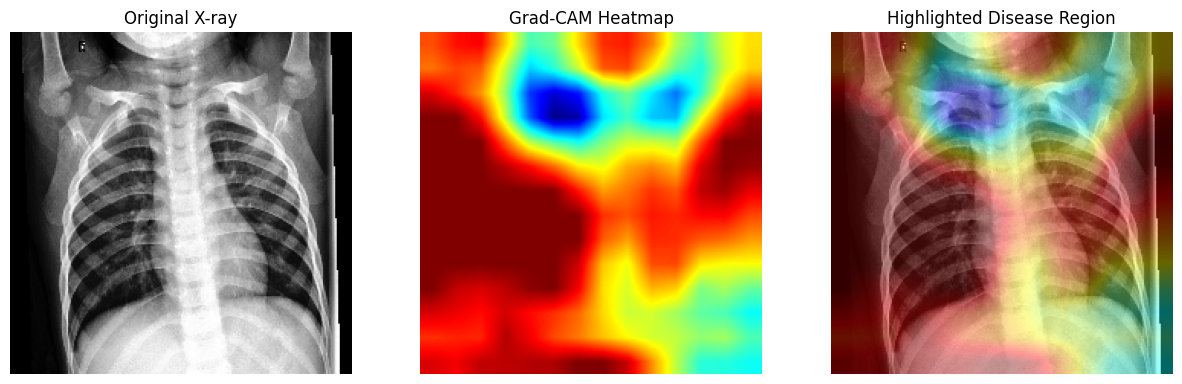

In [13]:
# ==========================================
# GRAD-CAM VISUALIZATION
# ==========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Function to generate Grad-CAM
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

# -------------------------------------------------
# Find last convolutional layer automatically
# -------------------------------------------------

last_conv_layer = None

for layer in reversed(best_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

if last_conv_layer is None:
    print("No Conv2D layer found. Please specify the last convolution layer manually.")
else:

    heatmap = make_gradcam_heatmap(
        img_array,
        best_model,
        last_conv_layer
    )

    # Original image
    original = load_img(
        IMAGE_PATH,
        target_size=(224,224)
    )

    original = img_to_array(original).astype("uint8")

    # Resize heatmap
    heatmap = cv2.resize(
        heatmap,
        (224,224)
    )

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    superimposed = cv2.addWeighted(
        original,
        0.6,
        heatmap,
        0.4,
        0
    )

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(original)
    plt.title("Original X-ray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap)
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(superimposed)
    plt.title("Highlighted Disease Region")
    plt.axis("off")

    plt.show()

      AI PREDICTION CONFIDENCE REPORT
Normal              : 52.87%
Viral Pneumonia     : 39.78%
Covid               : 7.36%

Final Prediction : Normal
Confidence Score : 52.87%
Prediction Reliability : Low


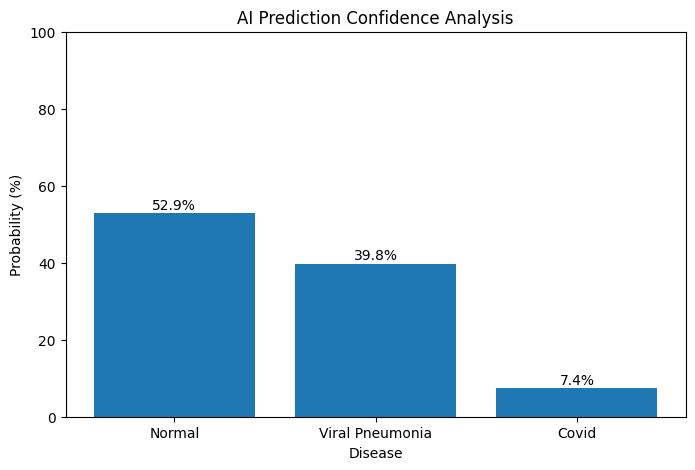

In [14]:
# ==========================================
# AI PREDICTION CONFIDENCE ANALYSIS
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# Get class names
classes = list(train_generator.class_indices.keys())

# Predict probabilities
pred = best_model.predict(img_array, verbose=0)[0]

# Convert to percentages
probabilities = pred * 100

# Sort from highest to lowest
sorted_idx = np.argsort(probabilities)[::-1]

sorted_classes = [classes[i] for i in sorted_idx]
sorted_probs = probabilities[sorted_idx]

# Print report
print("="*50)
print("      AI PREDICTION CONFIDENCE REPORT")
print("="*50)

for cls, prob in zip(sorted_classes, sorted_probs):
    print(f"{cls:<20}: {prob:.2f}%")

print("="*50)

# Best prediction
best_class = sorted_classes[0]
best_score = sorted_probs[0]

print(f"\nFinal Prediction : {best_class}")
print(f"Confidence Score : {best_score:.2f}%")

# Reliability message
if best_score >= 95:
    reliability = "Very High"
elif best_score >= 80:
    reliability = "High"
elif best_score >= 60:
    reliability = "Moderate"
else:
    reliability = "Low"

print(f"Prediction Reliability : {reliability}")

# Plot confidence graph
plt.figure(figsize=(8,5))

bars = plt.bar(sorted_classes, sorted_probs)

plt.xlabel("Disease")
plt.ylabel("Probability (%)")
plt.title("AI Prediction Confidence Analysis")
plt.ylim(0, 100)

# Add values above bars
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 1,
        f"{y:.1f}%",
        ha='center'
    )

plt.show()

In [15]:
# =====================================================
# ANIMATED AI LUNG DIAGNOSIS VISUALIZATION
# Generates: AI_Lung_Animation.gif
# =====================================================

# Install pillow if needed
# !pip install pillow

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# -----------------------------
# Load X-ray image
# -----------------------------
img = Image.open(IMAGE_PATH).convert("RGB")
img = img.resize((512,512))
img_np = np.array(img)

frames = []

# -----------------------------
# Frame 1 : Normal Lung
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img_np)
ax.set_title("STEP 1 : Chest X-Ray Loaded", fontsize=18)
ax.axis("off")
plt.savefig("frame1.png", bbox_inches='tight')
plt.close()

frames.append(Image.open("frame1.png"))

# -----------------------------
# Frame 2 : AI Detection
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img_np)

ax.text(
    20,
    40,
    "AI ANALYZING...",
    color="yellow",
    fontsize=20,
    bbox=dict(facecolor="black")
)

ax.axis("off")

plt.savefig("frame2.png", bbox_inches='tight')
plt.close()

frames.append(Image.open("frame2.png"))

# -----------------------------
# Frame 3 : Highlight Region
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img_np)

circle = plt.Circle(
    (260,250),
    80,
    color='red',
    fill=False,
    linewidth=5
)

ax.add_patch(circle)

ax.text(
    20,
    40,
    "SUSPICIOUS REGION",
    color="red",
    fontsize=18,
    bbox=dict(facecolor="white")
)

ax.axis("off")

plt.savefig("frame3.png", bbox_inches='tight')
plt.close()

frames.append(Image.open("frame3.png"))

# -----------------------------
# Frame 4 : Final Diagnosis
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img_np)

ax.text(
    20,
    40,
    f"Prediction : {disease}",
    fontsize=20,
    color="lime",
    bbox=dict(facecolor="black")
)

ax.text(
    20,
    90,
    f"Confidence : {confidence:.2f}%",
    fontsize=18,
    color="cyan",
    bbox=dict(facecolor="black")
)

ax.axis("off")

plt.savefig("frame4.png", bbox_inches='tight')
plt.close()

frames.append(Image.open("frame4.png"))

# -----------------------------
# Create GIF
# -----------------------------
frames[0].save(
    "AI_Lung_Animation.gif",
    save_all=True,
    append_images=frames[1:],
    duration=1500,
    loop=0
)

print("="*60)
print("Animation Created Successfully!")
print("Saved as: AI_Lung_Animation.gif")
print("="*60)

Animation Created Successfully!
Saved as: AI_Lung_Animation.gif


In [ ]:
# ==========================================================
# AI MEDICAL CHAT ASSISTANT (GEMINI API)
# ==========================================================

# Install package (run once)
!pip install -q google-generativeai

import google.generativeai as genai

# ----------------------------------------------------------
# ENTER YOUR GEMINI API KEY
# ----------------------------------------------------------
API_KEY = "API_KEY_GEMINI"

genai.configure(api_key=API_KEY)

# Load Gemini model
model = genai.GenerativeModel("gemini-2.5-flash")

print("="*70)
print("             AI MEDICAL CHAT ASSISTANT")
print("="*70)

# ----------------------------------------------------------
# Patient Details
# ----------------------------------------------------------

patient_name = input("Enter Patient Name : ")
age = input("Enter Age            : ")
gender = input("Enter Gender         : ")

print("\n")
print("="*70)
print("PATIENT SUMMARY")
print("="*70)
print(f"Patient Name : {patient_name}")
print(f"Age          : {age}")
print(f"Gender       : {gender}")
print(f"Predicted Disease : {disease}")
print(f"Confidence Score  : {confidence:.2f}%")
print("="*70)

print("""
You can ask questions like:

• Explain my disease
• What are the symptoms?
• What causes this disease?
• What tests are recommended?
• What treatments are available?
• What precautions should I take?
• What foods should I eat?
• How serious is my condition?

Type 'exit' to quit.
""")

# ----------------------------------------------------------
# Chat Loop
# ----------------------------------------------------------

while True:

    user_question = input("\nAsk AI: ")

    if user_question.lower() == "exit":
        print("\nThank you for using AI Medical Assistant.")
        break

    prompt = f"""
You are an experienced medical assistant.

Patient Information:
Name: {patient_name}
Age: {age}
Gender: {gender}

AI X-ray Prediction:
Disease: {disease}
Confidence: {confidence:.2f}%

User Question:
{user_question}

Please answer in simple language with the following sections whenever relevant:

1. Explanation
2. Possible Symptoms
3. Possible Causes
4. Recommended Diagnostic Tests
5. Treatment Options
6. Lifestyle & Prevention Tips
7. When to Seek Immediate Medical Care

End your response with this disclaimer:

'This information is AI-generated for educational purposes and is not a substitute for diagnosis or treatment by a qualified healthcare professional.'
"""

    try:
        response = model.generate_content(prompt)

        print("\n")
        print("="*70)
        print("AI MEDICAL ASSISTANT")
        print("="*70)
        print(response.text)
        print("="*70)

    except Exception as e:
        print("\nError:", e)
        print("Please verify that your Gemini API key is valid and that you have internet access.")

             AI MEDICAL CHAT ASSISTANT
Enter Patient Name : GOUTAM
Enter Age            : 21
Enter Gender         : FEMALE


PATIENT SUMMARY
Patient Name : GOUTAM
Age          : 21
Gender       : FEMALE
Predicted Disease : Normal
Confidence Score  : 52.87%

You can ask questions like:

• Explain my disease
• What are the symptoms?
• What causes this disease?
• What tests are recommended?
• What treatments are available?
• What precautions should I take?
• What foods should I eat?
• How serious is my condition?

Type 'exit' to quit.


Ask AI: WHAT TESTS ARE RECOMMENDED


AI MEDICAL ASSISTANT
Hello GOUTAM,

Here's an explanation based on the information provided:

### 1. Explanation

Your AI X-ray prediction indicates "Normal" but with a relatively low confidence level of 52.87%. This means that while the AI leans towards a normal finding, it's not very sure. It's important to remember that AI predictions are tools to assist doctors, not a final diagnosis.

**The most crucial piece of in

In [17]:
# ==========================================================
# EDUCATIONAL MEDICINE RECOMMENDATION
# ==========================================================

print("\n" + "="*70)
print("        EDUCATIONAL MEDICINE RECOMMENDATION")
print("="*70)

d = disease.lower()

if d == "covid":
    medicines = [
        ("Paracetamol", "500 mg (as advised by a doctor)", "May cause nausea or liver problems if overused"),
        ("ORS/Fluids", "Drink plenty of fluids", "No major side effects"),
        ("Vitamin C", "Once daily (if recommended)", "May cause stomach upset in some people")
    ]

elif d == "viral pneumonia":
    medicines = [
        ("Paracetamol", "500 mg (as advised by a doctor)", "May cause liver problems if overused"),
        ("Cough Syrup", "As prescribed by a doctor", "May cause drowsiness"),
        ("Plenty of Fluids & Rest", "Throughout the day", "No major side effects")
    ]

elif d == "normal":
    medicines = [
        ("No medication required", "-", "Maintain a healthy lifestyle")
    ]

else:
    medicines = [
        ("Consult a healthcare professional", "-", "-")
    ]

print(f"\nPredicted Disease : {disease}\n")

print("{:<30} {:<25} {}".format(
    "Medicine",
    "Educational Dosage",
    "Possible Side Effects"
))
print("-"*90)

for med in medicines:
    print("{:<30} {:<25} {}".format(
        med[0],
        med[1],
        med[2]
    ))

print("\nDoctor Consultation Advice:")
print("• Consult a qualified doctor before taking any medicine.")
print("• Do not self-medicate based on AI output.")
print("• Follow prescribed dosage and medical advice.")

print("\nDISCLAIMER:")
print("This section is generated for educational purposes only.")
print("It is NOT a medical prescription and should not replace")
print("professional diagnosis or treatment.")
print("="*70)


        EDUCATIONAL MEDICINE RECOMMENDATION

Predicted Disease : Normal

Medicine                       Educational Dosage        Possible Side Effects
------------------------------------------------------------------------------------------
No medication required         -                         Maintain a healthy lifestyle

Doctor Consultation Advice:
• Consult a qualified doctor before taking any medicine.
• Do not self-medicate based on AI output.
• Follow prescribed dosage and medical advice.

DISCLAIMER:
This section is generated for educational purposes only.
It is NOT a medical prescription and should not replace
professional diagnosis or treatment.


In [18]:
# ==================================================
# SEND AI MEDICAL REPORT VIA EMAIL
# ==================================================

import smtplib
from email.message import EmailMessage
import os

# -----------------------------
# Sender Details
# -----------------------------
sender_email = "bhatgoutam87@gmail.com"
app_password = "qwvu kcek xozg faxo"

# -----------------------------
# Receiver Details
# -----------------------------
receiver_email = input("Enter Patient/Doctor Email: ")

# -----------------------------
# Email Content
# -----------------------------
msg = EmailMessage()

msg["Subject"] = "AI Medical Report"

msg["From"] = sender_email
msg["To"] = receiver_email

body = f"""
AI MEDICAL REPORT

Predicted Disease : {disease}
Confidence Score  : {confidence:.2f}%

Recommendations:
• Please consult a qualified healthcare professional.
• Follow the prescribed medical advice.
• This report is AI-generated and for educational purposes only.

Thank you.
"""

msg.set_content(body)

# -----------------------------
# Attach PDF Report
# -----------------------------
pdf_file = "AI_Medical_Report.pdf"

if os.path.exists(pdf_file):

    with open(pdf_file, "rb") as f:
        file_data = f.read()

    msg.add_attachment(
        file_data,
        maintype="application",
        subtype="pdf",
        filename=pdf_file
    )

# -----------------------------
# Send Email
# -----------------------------
try:
    with smtplib.SMTP_SSL("smtp.gmail.com", 465) as smtp:
        smtp.login(sender_email, app_password)
        smtp.send_message(msg)

    print("\n✅ Email Sent Successfully!")

except Exception as e:
    print("\n❌ Error:", e)

Enter Patient/Doctor Email: ankithegde189@gmail.com

✅ Email Sent Successfully!


In [19]:
# ==========================================================
# CONCLUSION & AI RECOMMENDATION
# ==========================================================

print("\n" + "="*70)
print("                 AI MEDICAL REPORT CONCLUSION")
print("="*70)

print(f"\nPredicted Disease : {disease}")
print(f"Confidence Score  : {confidence:.2f}%")

# Reliability
if confidence >= 95:
    reliability = "Very High"
elif confidence >= 80:
    reliability = "High"
elif confidence >= 60:
    reliability = "Moderate"
else:
    reliability = "Low"

print(f"Prediction Reliability : {reliability}")

print("\nAI Suggestion:")

if disease.lower() == "normal":
    print("• No major abnormality detected in the X-ray.")
    print("• Maintain a healthy lifestyle and regular exercise.")
    print("• Continue routine medical check-ups.")

elif disease.lower() in ["viral pneumonia", "pneumonia"]:
    print("• Signs are suggestive of pneumonia.")
    print("• Consult a pulmonologist or physician promptly.")
    print("• Follow the prescribed medications and adequate rest.")
    print("• Seek immediate care if breathing difficulty increases.")

elif disease.lower() == "covid":
    print("• Findings may be consistent with COVID-related infection.")
    print("• Consult a healthcare professional for confirmation.")
    print("• Follow isolation and preventive measures if advised.")
    print("• Monitor oxygen saturation and symptoms.")

else:
    print("• Please consult a qualified healthcare professional.")
    print("• Additional diagnostic tests may be required.")
    print("• Do not rely solely on AI-generated results.")

print("\nFINAL CONCLUSION:")
print("This AI system analyzes chest X-ray images using deep learning")
print("to assist in disease detection and generate a preliminary report.")
print("The prediction should be used only as a decision-support tool")
print("and must always be confirmed by a qualified medical professional.")

print("\nDISCLAIMER:")
print("This report is generated by Artificial Intelligence for")
print("educational and research purposes only and is NOT a")
print("substitute for professional medical diagnosis or treatment.")

print("="*70)
print("           THANK YOU FOR USING AI MEDICAL REPORT")
print("="*70)


                 AI MEDICAL REPORT CONCLUSION

Predicted Disease : Normal
Confidence Score  : 52.87%
Prediction Reliability : Low

AI Suggestion:
• No major abnormality detected in the X-ray.
• Maintain a healthy lifestyle and regular exercise.
• Continue routine medical check-ups.

FINAL CONCLUSION:
This AI system analyzes chest X-ray images using deep learning
to assist in disease detection and generate a preliminary report.
The prediction should be used only as a decision-support tool
and must always be confirmed by a qualified medical professional.

DISCLAIMER:
This report is generated by Artificial Intelligence for
educational and research purposes only and is NOT a
substitute for professional medical diagnosis or treatment.
           THANK YOU FOR USING AI MEDICAL REPORT
